In [8]:
import json
# import plotly.express as px
import pandas as pd
# import openpyxl
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Tender schedule with starting point

In [2]:
with open('Deterministic_results_with_start.json') as json_file:
    F_results = json.load(json_file)


In [3]:
# Search results by keyword for F (tender schedules)
# List of keywords to search for
keywords_to_search = ["F"]

# Initialize a dictionary to store grouped results
grouped_results = {keyword: [] for keyword in keywords_to_search}

# Search for keywords in the JSON keys and group the results
for key, value in F_results.items():
    for keyword in keywords_to_search:
        if keyword in key:
            grouped_results[keyword].append({key: value})

# Print the grouped results
# for keyword, results in grouped_results.items():
#     print(f'Keyword: {keyword}')
#     for result in results:
#         print(f'  {result}')
#     print()


In [4]:
# create dictionary from F data from above
# Extracting information from the dictionary
data_list = []
for item in grouped_results['F']:
    key, value = list(item.items())[0]
    # print(key)
    tender = key.split('[', 1)[1].split(',', 1)[0]
    start, finish = eval(key.split('(', 1)[1].split(')', 1)[0])
    value = item[key]
    
    data_list.append({'Tender': tender, 'Start': start, 'Finish': finish, 'Value': value})

# Create a DataFrame
F_values_df = pd.DataFrame(data_list)

# Display the DataFrame
F_values_df.head()


,Tender,Start,Finish,Value
0,Tetanus,6,8,-0.0
1,Pertussis,6,6,-0.0
2,Pertussis,7,8,-0.0
3,Rubella,7,9,-0.0
4,Rubella,7,7,-0.0


In [5]:
#check to make sure all tenders are accounted for in model results
def lists_contain_same_strings(list1, list2):
    return set(list1) == set(list2)

# Example usage
list_a = list(F_values_df.Tender.unique())
list_b = ["Measles","Mumps","Rubella","Diphtheria","Tetanus","Pertussis",
          "Hepatitis_B","Hib","Polio","HPV","Rotavirus","PCV"]

lists_contain_same_strings(list_a, list_b)


True

C:\Users\nicho\AppData\Local\Temp\ipykernel_11760\4243563804.py:26: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colormap = plt.cm.get_cmap('grey', len(F_values_df))


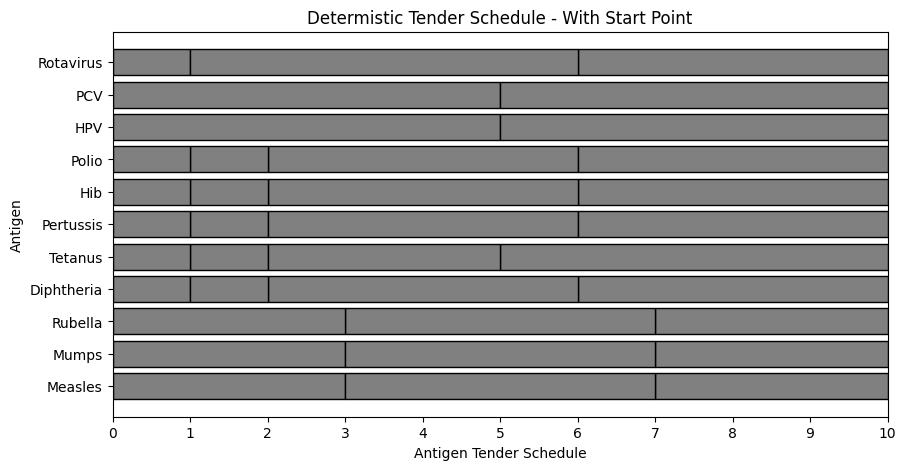

In [28]:
# plot the F (tenders) schedule to visualize results
# Define the desired order
tender_order = ['Measles', 'Mumps', 'Rubella', 'Diphtheria', 'Tetanus', 'Pertussis', 'Hib', 'Polio', 'HPV', 'PCV', 'Rotavirus']

# Convert the 'Tender' column to a categorical data type with the specified order
F_values_df['Tender'] = pd.Categorical(F_values_df['Tender'], categories=tender_order, ordered=True)

# Sort the DataFrame based on the categorical order
F_values_df = F_values_df.sort_values('Tender')

# Create a new figure and axis
fig, ax = plt.subplots(figsize=(10, 5))

# Create a colormap
# colormap = plt.cm.get_cmap('grey', len(F_values_df))

# Iterate through rows and plot bars based on conditions
for index, row in F_values_df.iterrows():
    if row['Value'] == 1:
        start = row['Start'] - 1
        end = row['Finish']
        
        # Choose color based on the index (tender)
        # color = colormap(index)
        ax.barh(row['Tender'], width=end - start, left=start, edgecolor='black', color='grey')


# Set labels and show the plot
ax.set_xlim(0, 10)
ax.set_xticks(range(11))

ax.set_xlabel('Antigen Tender Schedule')
ax.set_ylabel('Antigen')
plt.title('Determistic Tender Schedule - With Start Point')
plt.savefig('Deterministic_Tenders_With_Start_all_lengths.png')
plt.show()


## Tender Schedule without starting point

In [ ]:
with open('Deterministic_results.json') as json_file:
    F_results_clean = json.load(json_file)

In [ ]:
# Search results by keyword for F (tender schedules)
# List of keywords to search for
keywords_to_search = ["F"]

# Initialize a dictionary to store grouped results
grouped_results_clean = {keyword: [] for keyword in keywords_to_search}

# Search for keywords in the JSON keys and group the results
for key, value in F_results_clean.items():
    for keyword in keywords_to_search:
        if keyword in key:
            grouped_results_clean[keyword].append({key: value})

# Print the grouped results
# for keyword, results in grouped_results_clean.items():
#     print(f'Keyword: {keyword}')
#     for result in results:
#         print(f'  {result}')
#     print()


In [ ]:
# create dictionary from F data from above
# Extracting information from the dictionary
data_list = []
for item in grouped_results_clean['F']:
    key, value = list(item.items())[0]
    # print(key)
    tender = key.split('[', 1)[1].split(',', 1)[0]
    start, finish = eval(key.split('(', 1)[1].split(')', 1)[0])
    value = item[key]
    
    data_list.append({'Tender': tender, 'Start': start, 'Finish': finish, 'Value': value})

# Create a DataFrame
F_values_clean_df = pd.DataFrame(data_list)

# Display the DataFrame
F_values_clean_df.head()


In [ ]:
#check to make sure all tenders are accounted for in model results
def lists_contain_same_strings(list1, list2):
    return set(list1) == set(list2)

# Example usage
list_a = list(F_values_clean_df.Tender.unique())
list_b = ["Measles","Mumps","Rubella","Diphtheria","Tetanus","Pertussis",
          "Hepatitis_B","Hib","Polio","HPV","Rotavirus","PCV"]

lists_contain_same_strings(list_a, list_b)


In [ ]:
# plot the F (tenders) schedule to visualize results
# Create a new figure and axis
fig, ax = plt.subplots(figsize=(10, 5))

# Iterate through rows and plot bars based on conditions
for index, row in F_values_clean_df.iterrows():
    if row['Value'] == 1:
        start = row['Start']-1
        end = row['Finish'] 
        ax.barh(row['Tender'], width=end - start, left=start, edgecolor='black')

# Set labels and show the plot
ax.set_xlim(0, 10)
ax.set_xticks(range(11))

ax.set_xlabel('Antigen Tender Schedule')
ax.set_ylabel('Antigen')
plt.title('Determistic Tender Schedule')
plt.savefig('Deterministic_Tenders.png')
plt.show()
